# OSM Tag Exploration

This notebook explores the additional information stored in the OpenStreetMap `tags` field and identifies tags that may provide useful evidence for building classification.

**Input**
- Cleaned OpenStreetMap building data, including the raw `tags` field.

**Output**
- An inventory of available OSM tag keys and their frequencies.
- Selected classification-relevant tags extracted into separate building attributes for subsequent mapping.

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, sys
import ast, json, re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})




ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)


In [2]:
print("Loading Germany Data...")

# 1. Load Parquet files
gdf_bldg = gpd.read_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned02.parquet'))

print("Data loaded successfully!")

Loading Germany Data...
Data loaded successfully!


In [3]:
df_raw = gdf_bldg.copy()

In [4]:
# 1. Count total buildings tagged exactly as 'yes'
mask_yes = df_raw['building'] == 'yes'
total_yes = mask_yes.sum()

# 2. Count how many of those 'yes' buildings ALSO have data in the tags column
mask_yes_with_tags = mask_yes & df_raw['tags'].notna()
yes_with_tags = mask_yes_with_tags.sum()

# 3. Calculate and print the results
if total_yes > 0:
    pct = (yes_with_tags / total_yes) * 100
    print("=== BUILDING=YES TAG RECOVERY OPPORTUNITY ===")
    print(f"Total 'building=yes' rows            : {total_yes:>12,}")
    print(f"How many of those have extra tags    : {yes_with_tags:>12,}")
    print(f"Percentage we might be able to rescue: {pct:>11.1f}%")
else:
    print("No 'building=yes' found in the dataset.")

=== BUILDING=YES TAG RECOVERY OPPORTUNITY ===
Total 'building=yes' rows            :   25,834,104
How many of those have extra tags    :    3,766,594
Percentage we might be able to rescue:        14.6%


In [5]:
# Look at 30 non-null samples to understand format
tags_sample = df_raw[df_raw['tags'].notna()]['tags'].sample(30, random_state=42)

print('=== RAW FORMAT INSPECTION (30 samples) ===')
for i, (idx, val) in enumerate(tags_sample.items()):
    print(f'\n[{i}] type={type(val).__name__}')
    val_str = str(val)
    print(f'    {val_str[:200]}{"..." if len(val_str) > 200 else ""}')


=== RAW FORMAT INSPECTION (30 samples) ===

[0] type=str
    {"roof:orientation":"across","roof:shape":"gabled"}

[1] type=str
    {"roof:levels":"1","roof:orientation":"across","roof:shape":"gabled"}

[2] type=str
    {"roof:levels":"1"}

[3] type=str
    {"addr:suburb":"Bollensdorf","roof:levels":"1","roof:shape":"gabled"}

[4] type=str
    {"addr:suburb":"Querum","roof:levels":"0"}

[5] type=str
    {"roof:levels":"0","roof:material":"tar_paper","roof:shape":"flat"}

[6] type=str
    {"power":"substation"}

[7] type=str
    {"addr:suburb":"Sevelen"}

[8] type=str
    {"addr:suburb":"Gr\u00E4finau-Angstedt","roof:shape":"hipped"}

[9] type=str
    {"house":"terraced","roof:orientation":"across","roof:shape":"gabled"}

[10] type=str
    {"addr:suburb":"Beuern"}

[11] type=str
    {"layer":"1"}

[12] type=str
    {"addr:suburb":"Hochstadt","note:de":"Am 16.02.2016 war das Geb\u00E4ude noch nicht auf dem Luftbild. Position wurde nach Ortsbesichtigung gesch\u00E4tzt. Genau Position muss 

In [6]:
# Detect the dominant format type
type_counts = df_raw['tags'].dropna().apply(lambda x: type(x).__name__).value_counts()
print('Value type distribution in tags column:')
print(type_counts.to_string())
print()

# Check if any are already dicts
n_dict = (df_raw['tags'].dropna().apply(type) == dict).sum()
n_str  = (df_raw['tags'].dropna().apply(type) == str).sum()
print(f'Already dict objects : {n_dict:,}')
print(f'String representations: {n_str:,}')

# Peek at first non-null value in detail
first_val = df_raw['tags'].dropna().iloc[0]
print(f'\nFirst non-null value:')
print(repr(first_val))


Value type distribution in tags column:
tags
str    8880877

Already dict objects : 0
String representations: 8,880,877

First non-null value:
'{"roof:shape":"gabled","sport":"equestrian"}'


In [7]:
# ── Safe parser that handles all formats ──────────────────────────────
def parse_tags(val):
    """
    Safely convert a tags value to a dict.
    Handles: dict, JSON string, Python dict repr string, None/NaN.
    Returns {} if unparseable.
    """
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return {}
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        s = val.strip()
        if not s or s in ('{}', 'nan', 'None'):
            return {}
        # Try JSON first (double quotes)
        try:
            return json.loads(s)
        except (json.JSONDecodeError, ValueError):
            pass
        # Try Python literal eval (single quotes)
        try:
            result = ast.literal_eval(s)
            if isinstance(result, dict):
                return result
        except (ValueError, SyntaxError):
            pass
        # Last resort: regex key=value extraction
        pairs = re.findall(r"['\"]([^'\"]+)['\"]\s*:\s*['\"]([^'\"]*)['\"](?:,|\})", s)
        if pairs:
            return dict(pairs)
    return {}

# Test the parser
test_vals = df_raw['tags'].dropna().head(100)
parsed_test = test_vals.apply(parse_tags)
n_empty = (parsed_test.apply(len) == 0).sum()
n_ok    = (parsed_test.apply(len) > 0).sum()
print(f'Parser test on 100 samples:')
print(f'  Successfully parsed (non-empty dict): {n_ok}')
print(f'  Returned empty dict                 : {n_empty}')
print()
print('Sample parsed result:')
print(parsed_test.iloc[0])


Parser test on 100 samples:
  Successfully parsed (non-empty dict): 100
  Returned empty dict                 : 0

Sample parsed result:
{'roof:shape': 'gabled', 'sport': 'equestrian'}


In [8]:
# ── Parse ALL tags and count key frequencies ──────────────────────────
# We only need keys (not values) for the frequency inventory.
# Using a Counter for speed.

print('Parsing tags column and counting key frequencies...')
print('(This may take a few minutes on the full dataset)')
print()

key_counter = Counter()
n_with_tags = 0
n_empty     = 0

TOTAL = len(df_raw)

CHUNK = 15_000_000  # process in chunks to show progress

for start in range(0, TOTAL, CHUNK):
    chunk = df_raw['tags'].iloc[start:start+CHUNK]
    for val in chunk:
        d = parse_tags(val)
        if d:
            key_counter.update(d.keys())
            n_with_tags += 1
        else:
            n_empty += 1
    pct = min((start + CHUNK) / TOTAL * 100, 100)
    print(f'  Progress: {pct:.0f}%  ({min(start+CHUNK,TOTAL):,} / {TOTAL:,} rows)')

print()
print(f'Buildings with at least one extra tag : {n_with_tags:,}  ({n_with_tags/TOTAL*100:.1f}%)')
print(f'Buildings with empty tags             : {n_empty:,}   ({n_empty/TOTAL*100:.1f}%)')
print(f'Total unique keys found               : {len(key_counter):,}')


Parsing tags column and counting key frequencies...
(This may take a few minutes on the full dataset)

  Progress: 39%  (15,000,000 / 38,802,372 rows)
  Progress: 77%  (30,000,000 / 38,802,372 rows)
  Progress: 100%  (38,802,372 / 38,802,372 rows)

Buildings with at least one extra tag : 8,880,877  (22.9%)
Buildings with empty tags             : 29,921,495   (77.1%)
Total unique keys found               : 7,604


In [9]:
# Convert to DataFrame for analysis
key_df = pd.DataFrame(
    key_counter.most_common(),
    columns=['key', 'n_buildings']
)
key_df['pct_of_total']      = key_df['n_buildings'] / TOTAL * 100
key_df['pct_of_tagged']     = key_df['n_buildings'] / n_with_tags * 100

print(f'Full key inventory: {len(key_df):,} unique keys')
print()
print('TOP 100 KEYS BY FREQUENCY:')
print(f'  {"Key":<40} {"Buildings":>12} {"% of all":>10} {"% of tagged":>13}')
print('-' * 80)
for _, row in key_df.head(100).iterrows():
    print(f'  {row["key"]:<40} {row["n_buildings"]:>12,} {row["pct_of_total"]:>9.3f}%  {row["pct_of_tagged"]:>12.1f}%')


Full key inventory: 7,604 unique keys

TOP 100 KEYS BY FREQUENCY:
  Key                                         Buildings   % of all   % of tagged
--------------------------------------------------------------------------------
  addr:suburb                                 3,757,767     9.684%          42.3%
  roof:shape                                  3,263,432     8.410%          36.7%
  roof:levels                                 2,416,113     6.227%          27.2%
  roof:orientation                              583,287     1.503%           6.6%
  roof:colour                                   575,215     1.482%           6.5%
  source:building                               536,600     1.383%           6.0%
  roof:material                                 354,244     0.913%           4.0%
  building:colour                               248,361     0.640%           2.8%
  source:geometry                               225,484     0.581%           2.5%
  source:outline                  

In [10]:
# save the key inventory for later use
key_df.to_csv(os.path.join(DATA_DIR, 'interim', 'building_tags_key_inventory.csv'), index=False)
print(f'Total keys: {len(key_df):,}')

Total keys: 7,604


In [11]:
# ── Coverage tiers ────────────────────────────────────────────────────
tier1 = key_df[key_df['n_buildings'] >= 10_000]
tier2 = key_df[(key_df['n_buildings'] >= 1_000) & (key_df['n_buildings'] < 10_000)]
tier3 = key_df[(key_df['n_buildings'] >= 100)   & (key_df['n_buildings'] < 1_000)]
tier4 = key_df[key_df['n_buildings'] < 100]

print('KEY FREQUENCY TIERS:')
print(f'  Tier 1 (>= 10,000 buildings) : {len(tier1):>5} unique keys  — HIGH SIGNAL potential')
print(f'  Tier 2 (1,000–9,999)         : {len(tier2):>5} unique keys  — MEDIUM SIGNAL')
print(f'  Tier 3 (100–999)             : {len(tier3):>5} unique keys  — RARE but mappable')
print(f'  Tier 4 (< 100 buildings)     : {len(tier4):>5} unique keys  — noise / one-off tags')
print()
print('We will focus on Tier 1 + Tier 2 (>= 1,000 buildings)')


KEY FREQUENCY TIERS:
  Tier 1 (>= 10,000 buildings) :    80 unique keys  — HIGH SIGNAL potential
  Tier 2 (1,000–9,999)         :   189 unique keys  — MEDIUM SIGNAL
  Tier 3 (100–999)             :   464 unique keys  — RARE but mappable
  Tier 4 (< 100 buildings)     :  6871 unique keys  — noise / one-off tags

We will focus on Tier 1 + Tier 2 (>= 1,000 buildings)


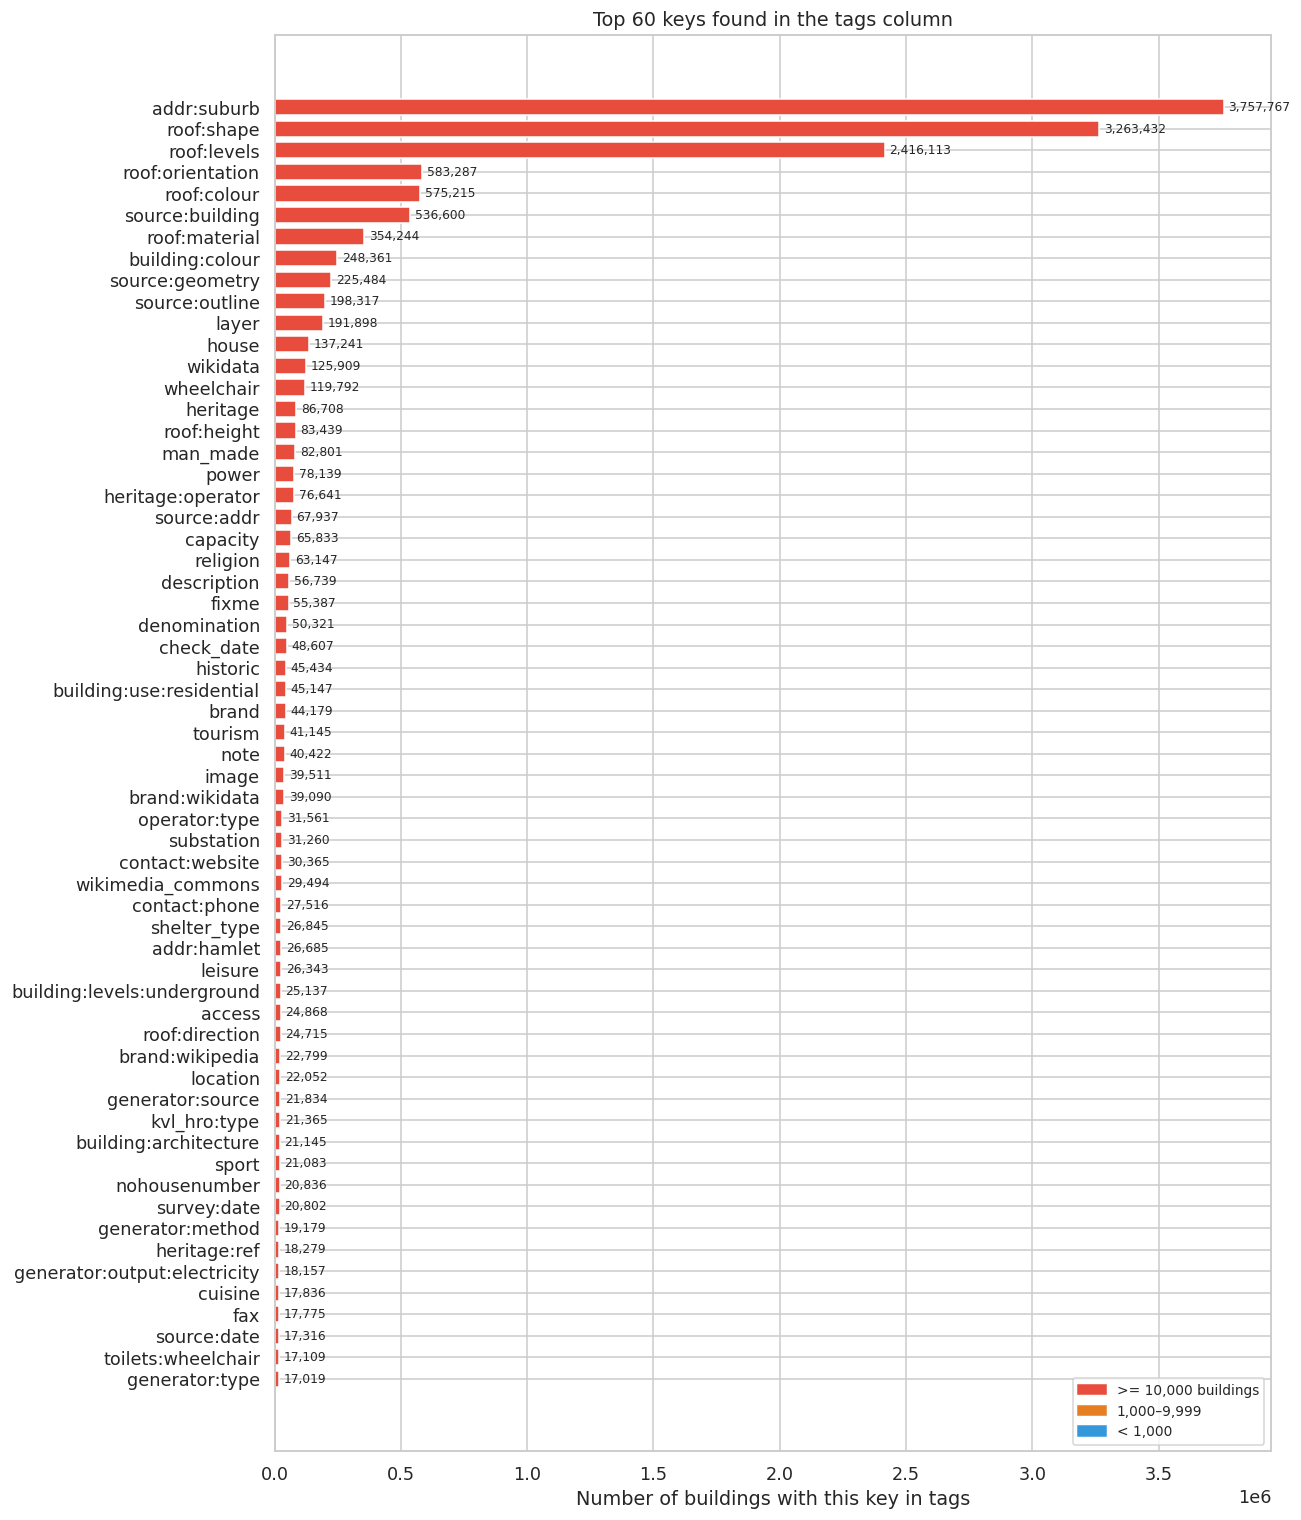

In [12]:
# ── Plot: top 60 keys by frequency ───────────────────────────────────
top50 = key_df.head(60)

fig, ax = plt.subplots(figsize=(12, 14))
colors = ['#e74c3c' if v >= 10_000 else '#e67e22' if v >= 1_000 else '#3498db'
          for v in top50['n_buildings']]
bars = ax.barh(top50['key'][::-1], top50['n_buildings'][::-1],
               color=colors[::-1], edgecolor='white', height=0.75)
for bar, val in zip(bars, top50['n_buildings'][::-1]):
    ax.text(bar.get_width() + max(top50['n_buildings'])*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
patches_leg = [
    mpatches.Patch(color='#e74c3c', label='>= 10,000 buildings'),
    mpatches.Patch(color='#e67e22', label='1,000–9,999'),
    mpatches.Patch(color='#3498db', label='< 1,000'),
]
ax.legend(handles=patches_leg, fontsize=9)
ax.set_xlabel('Number of buildings with this key in tags')
ax.set_title('Top 60 keys found in the tags column')
plt.tight_layout(); plt.show()


In [13]:
pd.set_option('display.max_rows', None)

In [14]:
# ── Manual key classification based on OSM wiki knowledge ───────────
# Edit this dict as you explore the values in Step 4

SIGNAL_KEYS = {
    # ── DIRECT TYPE SIGNALS ─────────────────────────────────────────────
    'proposed':           'apply_map',    
    'construction':       'apply_map',    
    'man_made':           'apply_map',   
    'power':              'apply_map',    
    'leisure':            'apply_map',   
    'tourism':            'apply_map',   
    'historic':           'apply_map',    
    'diocese':            'direct_map',    # civic.religious
    'building:type:de':   'apply_map',    
    'military':           'direct_map',    # civic.military
    'healthcare':         'direct_map',    # map all except hospital and rehabilitation (care_facility) to clinic
    'social_facility':    'direct_map',    # civic.care_facility
    'social_facility:for': 'direct_map',    # civic.care_facility 
    'building:use:retail': 'direct_map',    # if yes, commercial.retail
    'emergency':          'apply_map',   
    'aeroway':            'apply_map',   
    'railway':            'apply_map',    
    'public_transport':   'apply_map',    
    'building:type':     'apply_map',    # building:type=office → direct type or subtype depending on values
    'bunker_type':       'direct_map',    # military
    'house':              'apply_map',    
    'religion':          'direct_map',    # civic.religious
    'denomination':       'direct_map',    # civic.religious, if amenity =school, then school
    'building:use:residential': 'direct_map',    # if yes, residential
    'brand':             'direct_map',    # commercial, could be retail or food_drink
    'substation':         'direct_map',    # industrial.energy_production
    'cuisine':            'direct_map',    # commercial.food_drink
    'club':               'direct_map',    # civic.community - need to check osm building
    'community_centre':   'apply_map',    
    'parish':            'direct_map',    # civic.religious
    'bicycle_parking': 'filter',    
    'diet:vegetarian': 'direct_map',    # commercial.food_drink
    'government':         'apply_map',    
    'railway:signal_box': 'direct_map',  # transportation.maintenance
    'castle_type':        'direct_map',    # civic.cultural
    'healthcare:speciality': 'direct_map',    # civic.clinic - crosscheck
    'diet:vegan': 'direct_map',    # commercial.food_drink
    'second_hand': 'direct_map',    # commercial.retail
    'building:use:office': 'direct_map',    # if yes, commercial.office
    'drive_through': 'direct_map',    # commercial - crosscheck
    'delivery':            'direct_map',    # commercial. anything that has delivery should be commercial
    'organic':            'direct_map',    # commercial, could be retail or food_drink
    'service:vehicle:car_repair': 'direct_map',    # if yes, commercial.vehicle_service
    'education':           'direct_map', # all except from kindergarten, college and university    
    'disused:tourism': 'filter',    # filter.disused
    'diet:halal': 'direct_map',    # commercial, could be retail or food_drink
    'museum': 'direct_map',    # civic.cultural
    'building:use:education': 'direct_map',    # if yes, civic.school
    'brewery':            'direct_map',    # commercial
    'townhall:type': 'direct_map',    # civic.government_office


    
    # ── SUBTYPE / INDUSTRIAL SUBTYPE ────────────────────────────────────
    'industrial':         'direct_map',        # industrial - create mapping for it
    'product':            'direct_map',        # industrial.manufacturing
    'generator:source':   'direct_map',     # industrial.energy_production

    # ── FILTER / CONDITION ──────────────────────────────────────────────
    'disused':            'filter',         
    'disused:building':   'filter',        
    'abandoned':          'filter',        
    'demolished':         'filter',        
    'ruins':              'filter',
    'building:use:parking': 'filter',    
    'shelter_type':       'filter',   
    'bench':              'filter',          
    'parking':           'filter',         
    'disused:shop':     'filter',  
    'toilets:disposal': 'filter',    
    'abandoned:building': 'filter',  
    'disused:amenity': 'filter',   
}

# Separate by category
signal_keys   = {k for k, v in SIGNAL_KEYS.items() if v == 'direct_map'}
subtype_keys  = {k for k, v in SIGNAL_KEYS.items() if v == 'apply_map'}
filter_keys   = {k for k, v in SIGNAL_KEYS.items() if v == 'filter'}
feature_keys  = {k for k, v in SIGNAL_KEYS.items() if v == 'feature'}
location_keys = {k for k, v in SIGNAL_KEYS.items() if v == 'location'}
noise_keys    = {k for k, v in SIGNAL_KEYS.items() if v == 'noise'}

print('Key classification:')
print(f'  Direct type signals  : {len(signal_keys)}')
print(f'  Subtype signals      : {len(subtype_keys)}')
print(f'  Filter/condition     : {len(filter_keys)}')
print(f'  Feature engineering  : {len(feature_keys)}')
print(f'  Location enrichment  : {len(location_keys)}')
print(f'  Noise (drop)         : {len(noise_keys)}')
print()

# Check which of our signal keys actually appear in the data
all_useful = signal_keys | subtype_keys | filter_keys | feature_keys | location_keys
found_in_data    = set(key_df['key']) & all_useful
not_found_in_data = all_useful - set(key_df['key'])
print(f'Of {len(all_useful)} defined useful keys:')
print(f'  Found in data   : {len(found_in_data)} → these will be extracted')
print(f'  Not in data     : {len(not_found_in_data)} → these OSM tags not present in Germany buildings')
if not_found_in_data:
    print(f'  Keys not found  : {sorted(not_found_in_data)}')


Key classification:
  Direct type signals  : 35
  Subtype signals      : 16
  Filter/condition     : 15
  Feature engineering  : 0
  Location enrichment  : 0
  Noise (drop)         : 0

Of 66 defined useful keys:
  Found in data   : 66 → these will be extracted
  Not in data     : 0 → these OSM tags not present in Germany buildings


In [15]:
# ── Extract values for all useful keys in one full pass ───────────────
# One pass through all rows to extract everything at once.
# Faster than multiple passes.

print('Extracting values for useful keys (one full pass)...')
print()

ALL_EXTRACT_KEYS = list(signal_keys | subtype_keys | filter_keys | feature_keys | location_keys)

# Storage: key -> Counter of values
value_counters = {k: Counter() for k in ALL_EXTRACT_KEYS}
# Also store: for each building, a flat dict of extracted key-values
# (for later column extraction)
extracted_rows = []  # list of (row_index, {key: value, ...})

CHUNK = 15_000_000
for start in range(0, TOTAL, CHUNK):
    chunk_tags   = df_raw['tags'].iloc[start:start+CHUNK]
    chunk_build  = df_raw['building'].iloc[start:start+CHUNK] if 'building' in df_raw.columns else None

    for i, (idx, val) in enumerate(chunk_tags.items()):
        d = parse_tags(val)
        if not d:
            continue
        row_extract = {}
        for k in ALL_EXTRACT_KEYS:
            if k in d:
                v = str(d[k]).strip()
                value_counters[k][v] += 1
                row_extract[k] = v
        if row_extract:
            extracted_rows.append((idx, row_extract))

    pct = min((start + CHUNK) / TOTAL * 100, 100)
    print(f'  Progress: {pct:.0f}%  ({min(start+CHUNK, TOTAL):,} rows processed)')

print()
print(f'Rows with at least one useful key extracted: {len(extracted_rows):,}')
print()
print('Keys and value counts found:')
for k in sorted(ALL_EXTRACT_KEYS, key=lambda x: -sum(value_counters[x].values())):
    total = sum(value_counters[k].values())
    if total > 0:
        print(f'  {k:<35} {total:>10,} values across {len(value_counters[k]):>6,} unique values')


Extracting values for useful keys (one full pass)...

  Progress: 39%  (15,000,000 rows processed)
  Progress: 77%  (30,000,000 rows processed)
  Progress: 100%  (38,802,372 rows processed)

Rows with at least one useful key extracted: 701,517

Keys and value counts found:
  house                                  137,241 values across     64 unique values
  man_made                                82,801 values across    232 unique values
  power                                   78,139 values across     24 unique values
  religion                                63,147 values across     36 unique values
  denomination                            50,321 values across    198 unique values
  historic                                45,434 values across    241 unique values
  building:use:residential                45,147 values across      7 unique values
  brand                                   44,179 values across  2,954 unique values
  tourism                                 41,145 value

In [16]:
# ── Helper: print value distribution for a key ───────────────────────
def show_key_values(key, top_n=100):
    ctr = value_counters.get(key, Counter())
    if not ctr:
        print(f'  Key "{key}" not found or has no values.')
        return
    total_key = sum(ctr.values())
    print(f'KEY: {key}')
    print(f'  Total occurrences : {total_key:,}')
    print(f'  Unique values     : {len(ctr):,}')
    print()
    print(f'  {"Value":<45} {"Count":>10} {"% of key":>9}')
    print('  ' + '-' * 68)
    for val, cnt in ctr.most_common(top_n):
        print(f'  {str(val):<45} {cnt:>10,} {cnt/total_key*100:>8.2f}%')
    if len(ctr) > top_n:
        remaining = len(ctr) - top_n
        print(f'  ... and {remaining:,} more values with lower counts')
    print()


In [17]:
# ── Quantify recovery opportunity ─────────────────────────────────────
n_proposed     = (df_raw['building'] == 'proposed').sum()   if 'building' in df_raw.columns else 0
n_construction = (df_raw['building'] == 'construction').sum() if 'building' in df_raw.columns else 0

prop_with_tag  = sum(value_counters['proposed'].values())
cons_with_tag  = sum(value_counters['construction'].values())

print('RECOVERY OPPORTUNITY:')
print(f'  Buildings tagged building=proposed     : {n_proposed:,}')
print(f'    of which have proposed=* in tags     : {prop_with_tag:,}  ({prop_with_tag/max(n_proposed,1)*100:.1f}%)')
print()
print(f'  Buildings tagged building=construction : {n_construction:,}')
print(f'    of which have construction=* in tags : {cons_with_tag:,}  ({cons_with_tag/max(n_construction,1)*100:.1f}%)')
print()
print('These will be mapped to their actual type in the extraction step.')


RECOVERY OPPORTUNITY:
  Buildings tagged building=proposed     : 1,395
    of which have proposed=* in tags     : 1,324  (94.9%)

  Buildings tagged building=construction : 12,511
    of which have construction=* in tags : 7,233  (57.8%)

These will be mapped to their actual type in the extraction step.


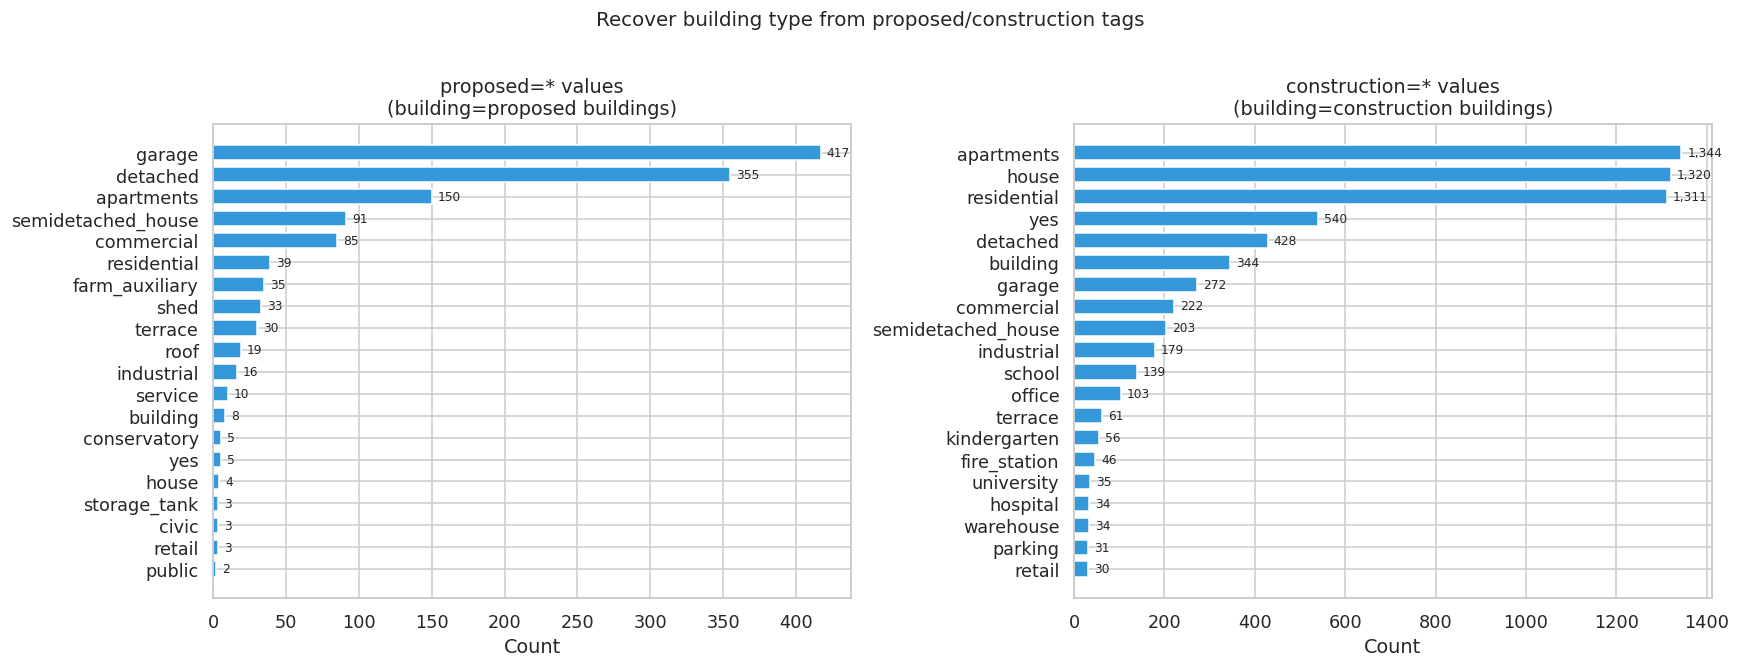

In [18]:
# ── Plot: proposed & construction value distributions ────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, key, title in [
    (axes[0], 'proposed',     'proposed=* values\n(building=proposed buildings)'),
    (axes[1], 'construction', 'construction=* values\n(building=construction buildings)'),
]:
    ctr = value_counters[key]
    if not ctr:
        ax.set_title(f'{title}\n(no data)'); continue
    top = pd.Series(dict(ctr.most_common(20)))
    top = top.sort_values()
    bars = ax.barh(top.index.astype(str), top.values, color='#3498db', edgecolor='white', height=0.7)
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + max(top.values)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)
    ax.set_xlabel('Count'); ax.set_title(title)

plt.suptitle('Recover building type from proposed/construction tags', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


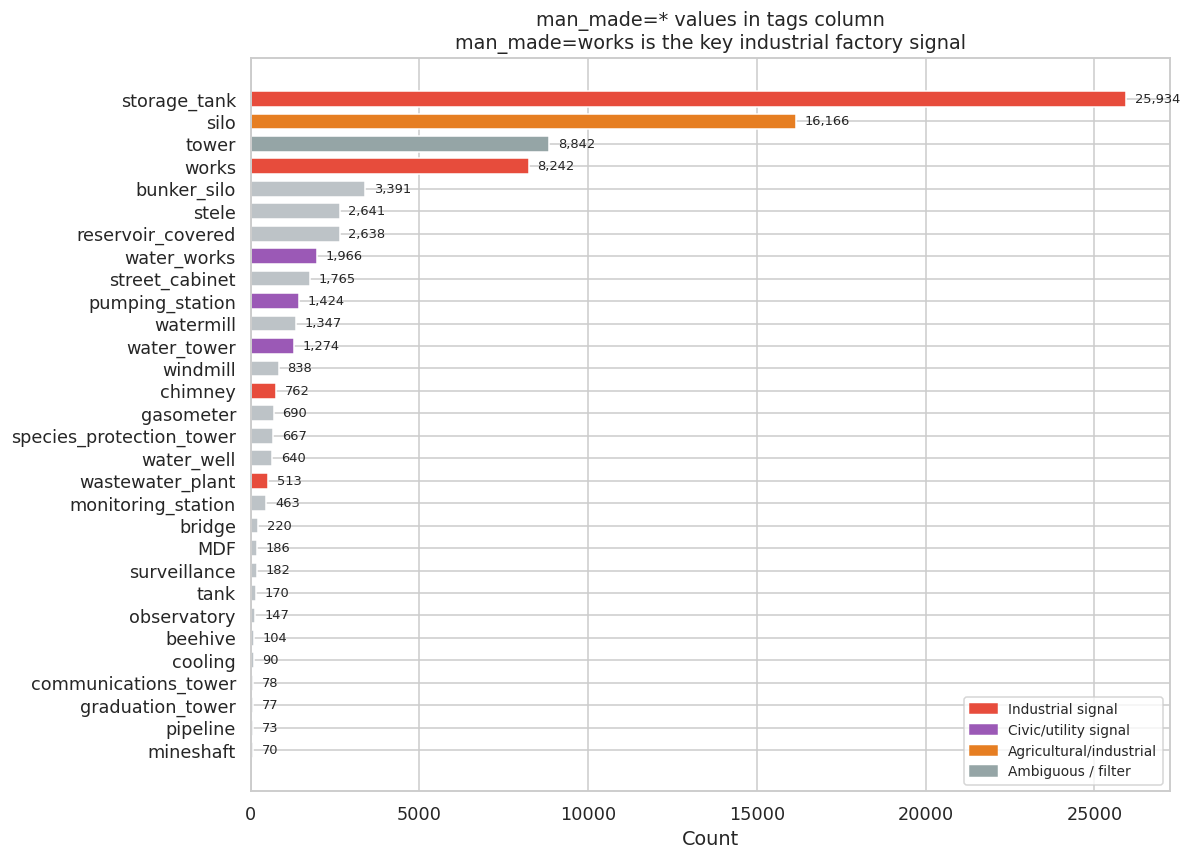

In [19]:
# ── Plot: man_made value distribution ────────────────────────────────
ctr = value_counters['man_made']
if ctr:
    top = pd.Series(dict(ctr.most_common(30))).sort_values()
    
    # Color by classification potential
    MANMADE_COLORS = {
        'works':          '#e74c3c',   # industrial
        'chimney':        '#e74c3c',
        'storage_tank':   '#e74c3c',
        'wastewater_plant': '#e74c3c',
        'water_works':    '#9b59b6',   # civic/utility
        'water_tower':    '#9b59b6',
        'pumping_station':'#9b59b6',
        'tower':          '#95a5a6',   # ambiguous
        'silo':           '#e67e22',   # agricultural/industrial
        'pier':           '#95a5a6',   # filter
    }
    colors = [MANMADE_COLORS.get(k, '#bdc3c7') for k in top.index]
    
    fig, ax = plt.subplots(figsize=(11, 8))
    bars = ax.barh(top.index, top.values, color=colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + max(top.values)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8.5)
    
    patches_leg = [
        mpatches.Patch(color='#e74c3c', label='Industrial signal'),
        mpatches.Patch(color='#9b59b6', label='Civic/utility signal'),
        mpatches.Patch(color='#e67e22', label='Agricultural/industrial'),
        mpatches.Patch(color='#95a5a6', label='Ambiguous / filter'),
    ]
    ax.legend(handles=patches_leg, fontsize=9)
    ax.set_xlabel('Count')
    ax.set_title('man_made=* values in tags column\n'
                 'man_made=works is the key industrial factory signal')
    plt.tight_layout(); plt.show()


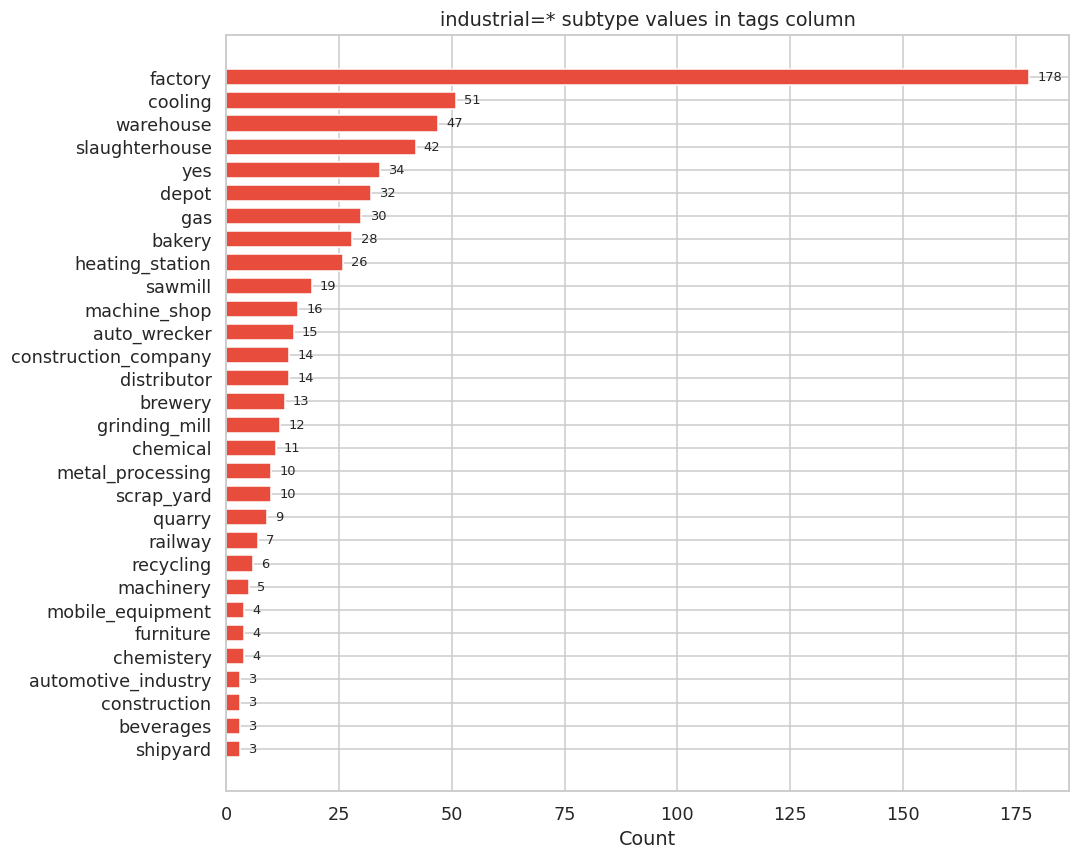

In [20]:
# ── Plot: industrial subtype values ──────────────────────────────────
ctr = value_counters['industrial']
if ctr:
    top = pd.Series(dict(ctr.most_common(30))).sort_values()
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top.index, top.values, color='#e74c3c', edgecolor='white', height=0.7)
    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + max(top.values)*0.01,
                bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8.5)
    ax.set_xlabel('Count')
    ax.set_title('industrial=* subtype values in tags column')
    plt.tight_layout(); plt.show()


In [21]:
# ── Rebuild extracted values as a DataFrame to merge ─────────────────
print('Building extracted-values DataFrame...')

# Convert extracted_rows list to a lookup dict: index → {key: value}
extract_lookup = {}
for idx, kv in extracted_rows:
    if idx not in extract_lookup:
        extract_lookup[idx] = {}
    extract_lookup[idx].update(kv)

# Build DataFrame aligned to df_raw
extract_df = pd.DataFrame.from_dict(extract_lookup, orient='index', columns=ALL_EXTRACT_KEYS)
extract_df = extract_df.reindex(df_raw.index)   # align to original index

print(f'Extracted DataFrame shape: {extract_df.shape}')
print()
print('Coverage of extracted columns:')
for col in sorted(extract_df.columns):
    n = extract_df[col].notna().sum()
    if n > 0:
        print(f'  {col:<35} {n:>10,}  ({n/TOTAL*100:.3f}%)')


Building extracted-values DataFrame...
Extracted DataFrame shape: (38802372, 66)

Coverage of extracted columns:
  abandoned                                8,722  (0.022%)
  abandoned:building                       1,212  (0.003%)
  aeroway                                  1,850  (0.005%)
  bench                                    9,474  (0.024%)
  bicycle_parking                          3,753  (0.010%)
  brand                                   44,179  (0.114%)
  brewery                                    702  (0.002%)
  building:type                            2,994  (0.008%)
  building:type:de                         4,667  (0.012%)
  building:use:education                     675  (0.002%)
  building:use:office                      1,527  (0.004%)
  building:use:parking                    10,425  (0.027%)
  building:use:residential                45,147  (0.116%)
  building:use:retail                      2,801  (0.007%)
  bunker_type                              2,731  (0.007%)
  

In [22]:
# ── Merge extracted columns into master df ────────────────────────────
print('Merging extracted columns into master DataFrame...')

# Prefix all extracted tag columns to avoid name collision
rename_map = {col: f'tags_{col}' for col in extract_df.columns}
extract_df_renamed = extract_df.rename(columns=rename_map)

# Add to main df (only new columns that don't already exist)
new_cols = [c for c in extract_df_renamed.columns if c not in df_raw.columns]
df_enriched = pd.concat([df_raw, extract_df_renamed[new_cols]], axis=1)

print(f'Columns before : {len(df_raw.columns)}')
print(f'New tag columns added: {len(new_cols)}')
print(f'Columns after  : {len(df_enriched.columns)}')
print()
print('New columns added:')
for c in new_cols:
    n = df_enriched[c].notna().sum()
    print(f'  {c:<40} {n:>10,} non-null')


Merging extracted columns into master DataFrame...
Columns before : 19
New tag columns added: 66
Columns after  : 85

New columns added:
  tags_power                                   78,139 non-null
  tags_education                                  991 non-null
  tags_man_made                                82,801 non-null
  tags_substation                              31,260 non-null
  tags_emergency                                3,828 non-null
  tags_proposed                                 1,324 non-null
  tags_demolished                                  47 non-null
  tags_ruins                                    5,467 non-null
  tags_house                                  137,241 non-null
  tags_parish                                   4,060 non-null
  tags_government                               2,252 non-null
  tags_delivery                                 2,041 non-null
  tags_shelter_type                            26,845 non-null
  tags_healthcare                           

In [23]:
df_enriched.shape

(38802372, 85)

In [24]:
df_enriched.to_parquet(os.path.join(DATA_DIR, 'interim', 'germany_buildings_cleaned_tags.parquet'), index=False)

In [25]:
df_enriched.head()

,addr:city,addr:housenumber,addr:postcode,addr:street,name,building,amenity,building:use,craft,office,...,tags_parking,tags_building:use:office,tags_social_facility:for,tags_building:use:retail,tags_diocese,tags_diet:vegan,tags_construction,tags_abandoned,tags_diet:halal,tags_cuisine
0,Weinheim,5,69469,Babostraße,Konferenzhaus Unternehmensgruppe Freudenberg,yes,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,None,None,Reithalle,riding_hall,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,None,None,None,None,None,yes,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,None,None,None,yes,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,None,None,None,None,None,yes,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
